## Testing the Gadget for the $^{18}\text{O}$ in the Quasiparticle Picture

We study the Gadget Ising Hamiltonian encoding for the Oxigen 18 in the quasiparticle representation, using the parametrized self-energy of the virtual states. We also compare the effect of using the $c_{AB}$ and without using it.

### Imports

In [32]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import (
    EffectiveInteractionOptimizer,
    EffectiveInteractionOptimizer2ndVersion,
)
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh, expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import (
    QuasiParticlesConverter,
    HardcoreBosonsBasis,
    QuasiParticlesConverterOnlynnpp,
)
from src.utils import generate_particleconservation_basis, array_to_qutip

### Load the coupling of the Quasiparticle Hamiltonian

We upload the $g^{(1)}_{AB}$ couplings from the numpy dictionary, we also fix the number of Qubit for the system that we are considering. Since the $^{19}\text{O}$ involves only one active quasiparticle neutron, we don't need any two-body interaction

In [33]:
# load the couplings computed through the quasiparticle class of NSMFermions
data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]
n_qubits = 6

g_onebody = {}
diagonal_elements = np.zeros(n_qubits)
g_matrix = np.zeros((n_qubits, n_qubits))
for a, key in enumerate(keys):
    i, j = key
    g_onebody[(i, j)] = values[a]
    if i != j:
        g_matrix[i, j] = values[a]
    if i == j:
        diagonal_elements[i] = values[a]


# we need a reference basis to compare the components of the Wavefunction
basis = computational_basis(n_qubits)

#### Study the Quasiparticle Hamiltonian with the Hardcore Boson Basis

We study the Hamiltonian in the Number sector, as we did in the previous projects. This is our Benchmark

In [34]:
nparticles_a = 1
nparticles_b = 0
# here we define the number sector basis
particle_conserved_basis = generate_particleconservation_basis(
    size_a=n_qubits,
    size_b=0,
    nparticles_a=nparticles_a,
    nparticles_b=nparticles_b,
)

print(particle_conserved_basis)

# initialize the class in the number sector of the quasiparticle space (see NSMFermion library)
HBB = HardcoreBosonsBasis(basis=particle_conserved_basis)
quasiparticle_nsm_hamiltonian_particle_conserved = 0.0
for key, value in g_onebody.items():
    idx_a, idx_b = key
    quasiparticle_nsm_hamiltonian_particle_conserved += value * HBB.adag_a_matrix(
        idx_a, idx_b
    )


energies_particle_sector, _ = np.linalg.eigh(
    quasiparticle_nsm_hamiltonian_particle_conserved.todense()
)

print(energies_particle_sector)

[[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]
[-11.93178825  -8.9655495   -8.0583      -7.33926256   3.07695081
   4.2394495 ]


#### Write the NSM Quasiparticle Hamiltonian

Defining the Quasiparticle Hamiltonian in the full Hilbert space

In [35]:
hamiltonian_xy = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0
for i in range(n_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_elements[i]], size=n_qubits, verbose=1
    ).qutip_op
nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

Get the eigenvalues and the eigenvectors

In [36]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

Get the grundstate in the particle sector with a comparison with the gs energy of the particle sector

In [37]:
gs_idx = np.argmin(np.abs(eigenvalues_nsm - energies_particle_sector[0]))
print(gs_idx)

38


Look at the Components of the groundstate wavefunction

In [38]:
psi = eigenstates_nsm[gs_idx].full().flatten()
print(psi.shape)

(64,)


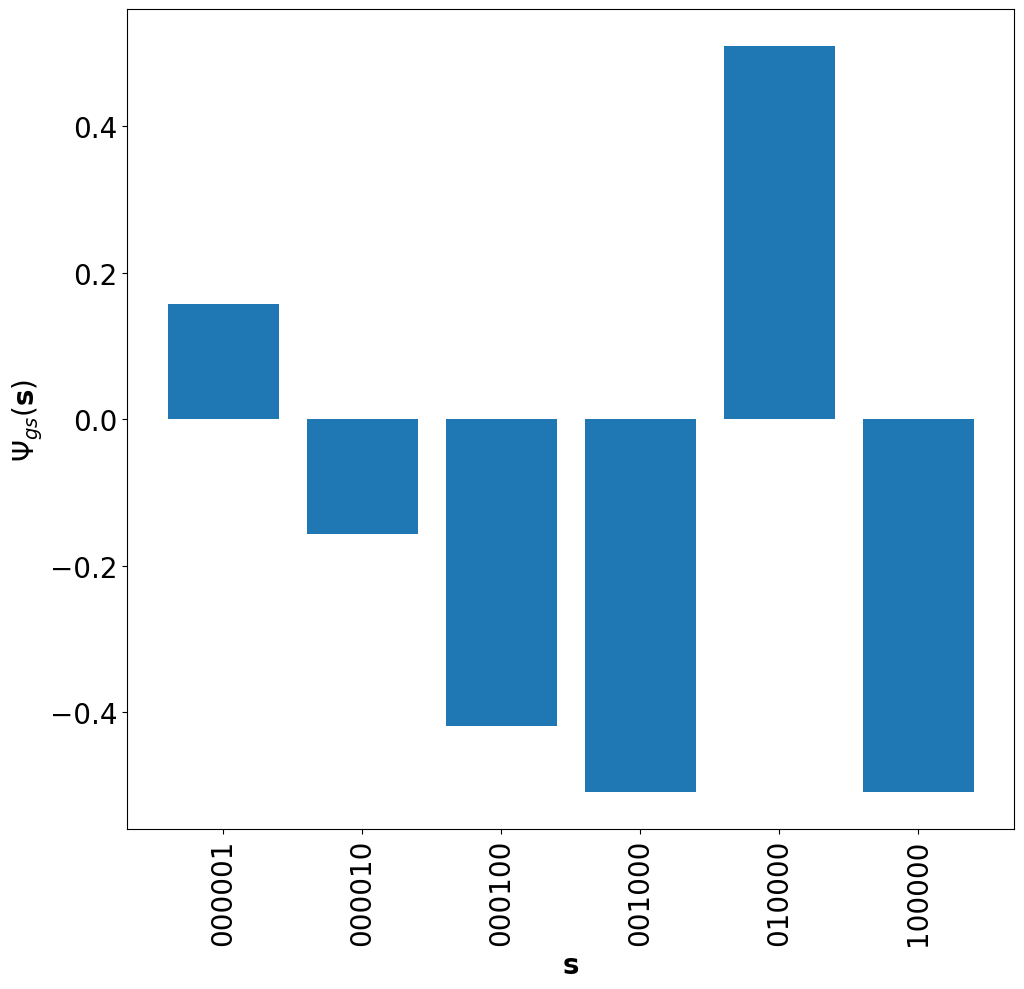

In [39]:
threshold = 1e-2
labels = ["".join(map(str, row)) for row in basis]
mask = np.abs(psi) > threshold
filtered_indices = np.where(mask)[0]
filtered_labels = [labels[i] for i in filtered_indices]
filtered_psi = psi[filtered_indices]

plt.figure(figsize=(10, 10))
plt.bar(range(len(filtered_psi)), np.real(filtered_psi))
plt.xticks(range(len(filtered_labels)), filtered_labels, rotation=90, fontsize=20)
plt.xlabel(r"$\mathbf{s}$", fontsize=20)
plt.ylabel(r"$\Psi_{gs}(\mathbf{s})$", fontsize=20)
plt.tight_layout()
plt.tick_params(labelsize=20)
plt.show()

### Puzzle of the Effective interaction

Following our notes on the gadget, we need to verify if we can reproduce the interaction by using the transverse field per site $d_i$. Since the relevant term in the effective Hamiltonian comes out as $H_{\text{int,eff}}=-\frac{1}{\gamma}\sum_{A \neq B} d_A d_B (X_A X_B +Y_A Y_B)$. We need to figure out if we can solve the condition $g_{AB}=-d_A d_B$. To do so, we treat it as an optimization problem. 

Optimal drive parameters: [ 0.90513022 -1.02535363  0.96153052  0.79417758  1.10508836 -1.13502171]


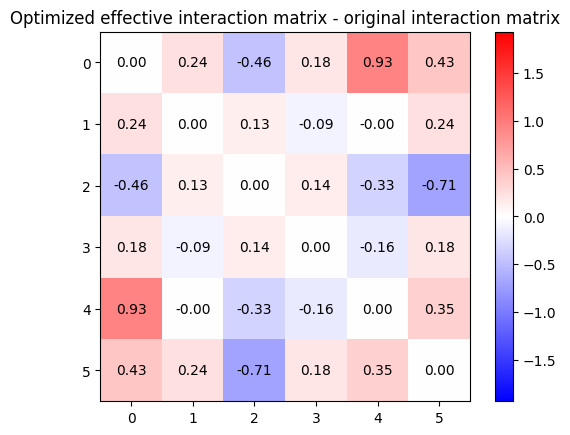

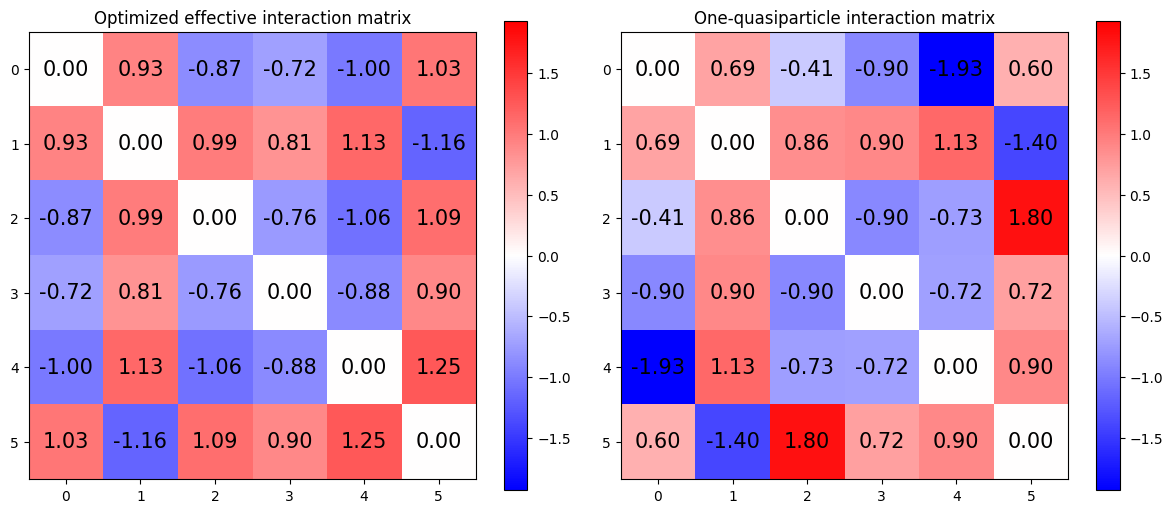

In [40]:
OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=n_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)

plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [OptimalFieldBe6.reconstructed(d_opt), g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(n_qubits):
        for j in range(n_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

##### Optimizing using the parametrized self-energy

In this case, after we get the optimal transverse field that reproduces at most the one-quasiparticle interaction, we explore the optimization of the $c_{AB}$ values to fill the gap between the effective interaction and the exact one.

In [ ]:
opt = EffectiveInteractionOptimizer2ndVersion(n_qubits)

# Stage 1 (uncomment to refit d from scratch instead of using a fixed d_star):
d_opt, res1 = opt.optimize_rank1(g_matrix)

# Stage 2: alpha_AB and c_AB on top of the fixed d_star
alpha_matrix, c_matrix, report, g_corrected = opt.get_alpha_and_c(g_matrix, d_opt)
opt.print_report(g_matrix, d_opt, alpha_matrix, c_matrix, report)

d (fixed ansatz): [-0.9051  1.0254 -0.9615 -0.7942 -1.1051  1.135 ]
Rank-1-only loss: 2.242931e+00

  pair     target      rank1    alpha_AB        c_AB   pole?                          branch
----------------------------------------------------------------------------------------------------
  (0,1)     0.6898     0.9281      0.7433      1.0554          alpha<1 (shrink/flip vs rank-1)
  (0,2)    -0.4063    -0.8703      0.4668    -16.0807          alpha<1 (shrink/flip vs rank-1)
  (0,3)    -0.9008    -0.7188      1.2531     -0.3361               alpha>1 (boost vs rank-1)
  (0,4)    -1.9314    -1.0002      1.9310     -0.6506               alpha>1 (boost vs rank-1)
  (0,5)     0.6017     1.0273      0.5857      4.8329          alpha<1 (shrink/flip vs rank-1)
  (1,2)     0.8599     0.9859      0.8722      0.3434          alpha<1 (shrink/flip vs rank-1)
  (1,3)     0.9008     0.8143      1.1062     -0.1752               alpha>1 (boost vs rank-1)
  (1,4)     1.1336     1.1331      1.0005   

Fixing the regularization

In [42]:
c_matrix[np.abs(c_matrix) > 4] = np.abs(c_matrix[np.abs(c_matrix) > 4])
print(c_matrix)

[[            nan  1.05544729e+00  1.60806689e+01 -3.36090849e-01
  -6.50585476e-01  4.83294793e+00]
 [ 1.05544729e+00             nan  3.43399139e-01 -1.75171331e-01
  -9.04476634e-04 -2.88337659e-01]
 [ 1.60806689e+01  3.43399139e-01             nan -2.64285408e-01
   1.61180543e+00 -5.64430936e-01]
 [-3.36090849e-01 -1.75171331e-01 -2.64285408e-01             nan
   5.73416200e-01  6.87974649e-01]
 [-6.50585476e-01 -9.04476634e-04  1.61180543e+00  5.73416200e-01
              nan  1.29095455e+00]
 [ 4.83294793e+00 -2.88337659e-01 -5.64430936e-01  6.87974649e-01
   1.29095455e+00             nan]]


Double check the performance of $c_{AB}$

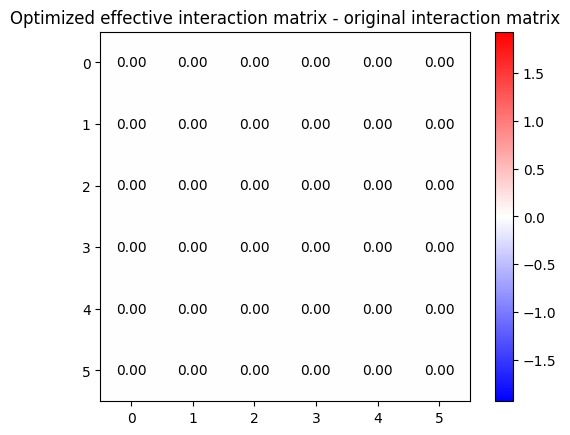

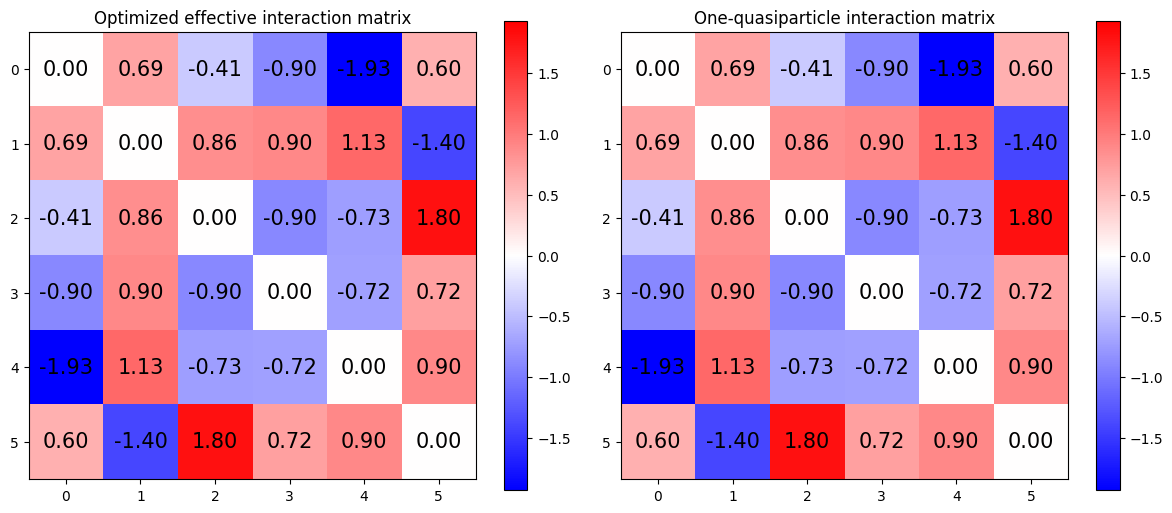

In [43]:
plt.imshow(
    g_corrected - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(
            j,
            i,
            f"{g_corrected[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [g_corrected, g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(n_qubits):
        for j in range(n_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Write the Diagonal part of the Ising Hamiltonian

Now, we have to write the full ising Hamiltonian that describes the constrain subspace, where our effective Hamiltonian acts, and then see how the spectrum behaves

#### Define the hamiltonian $H_z$ out of the couplings and constrains

In [44]:
# get the total particle constrain
gamma = 100  # gamma=100 is an example
ntot = 1
# we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[2 * gamma + gamma * c_matrix[i, j]],
            size=n_qubits,
            verbose=1,
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

longitudinal_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
)

#### Plot a representation of the diagonal part of the Ising Hamiltonian (USELESS SINCE TOO MANY STATES)

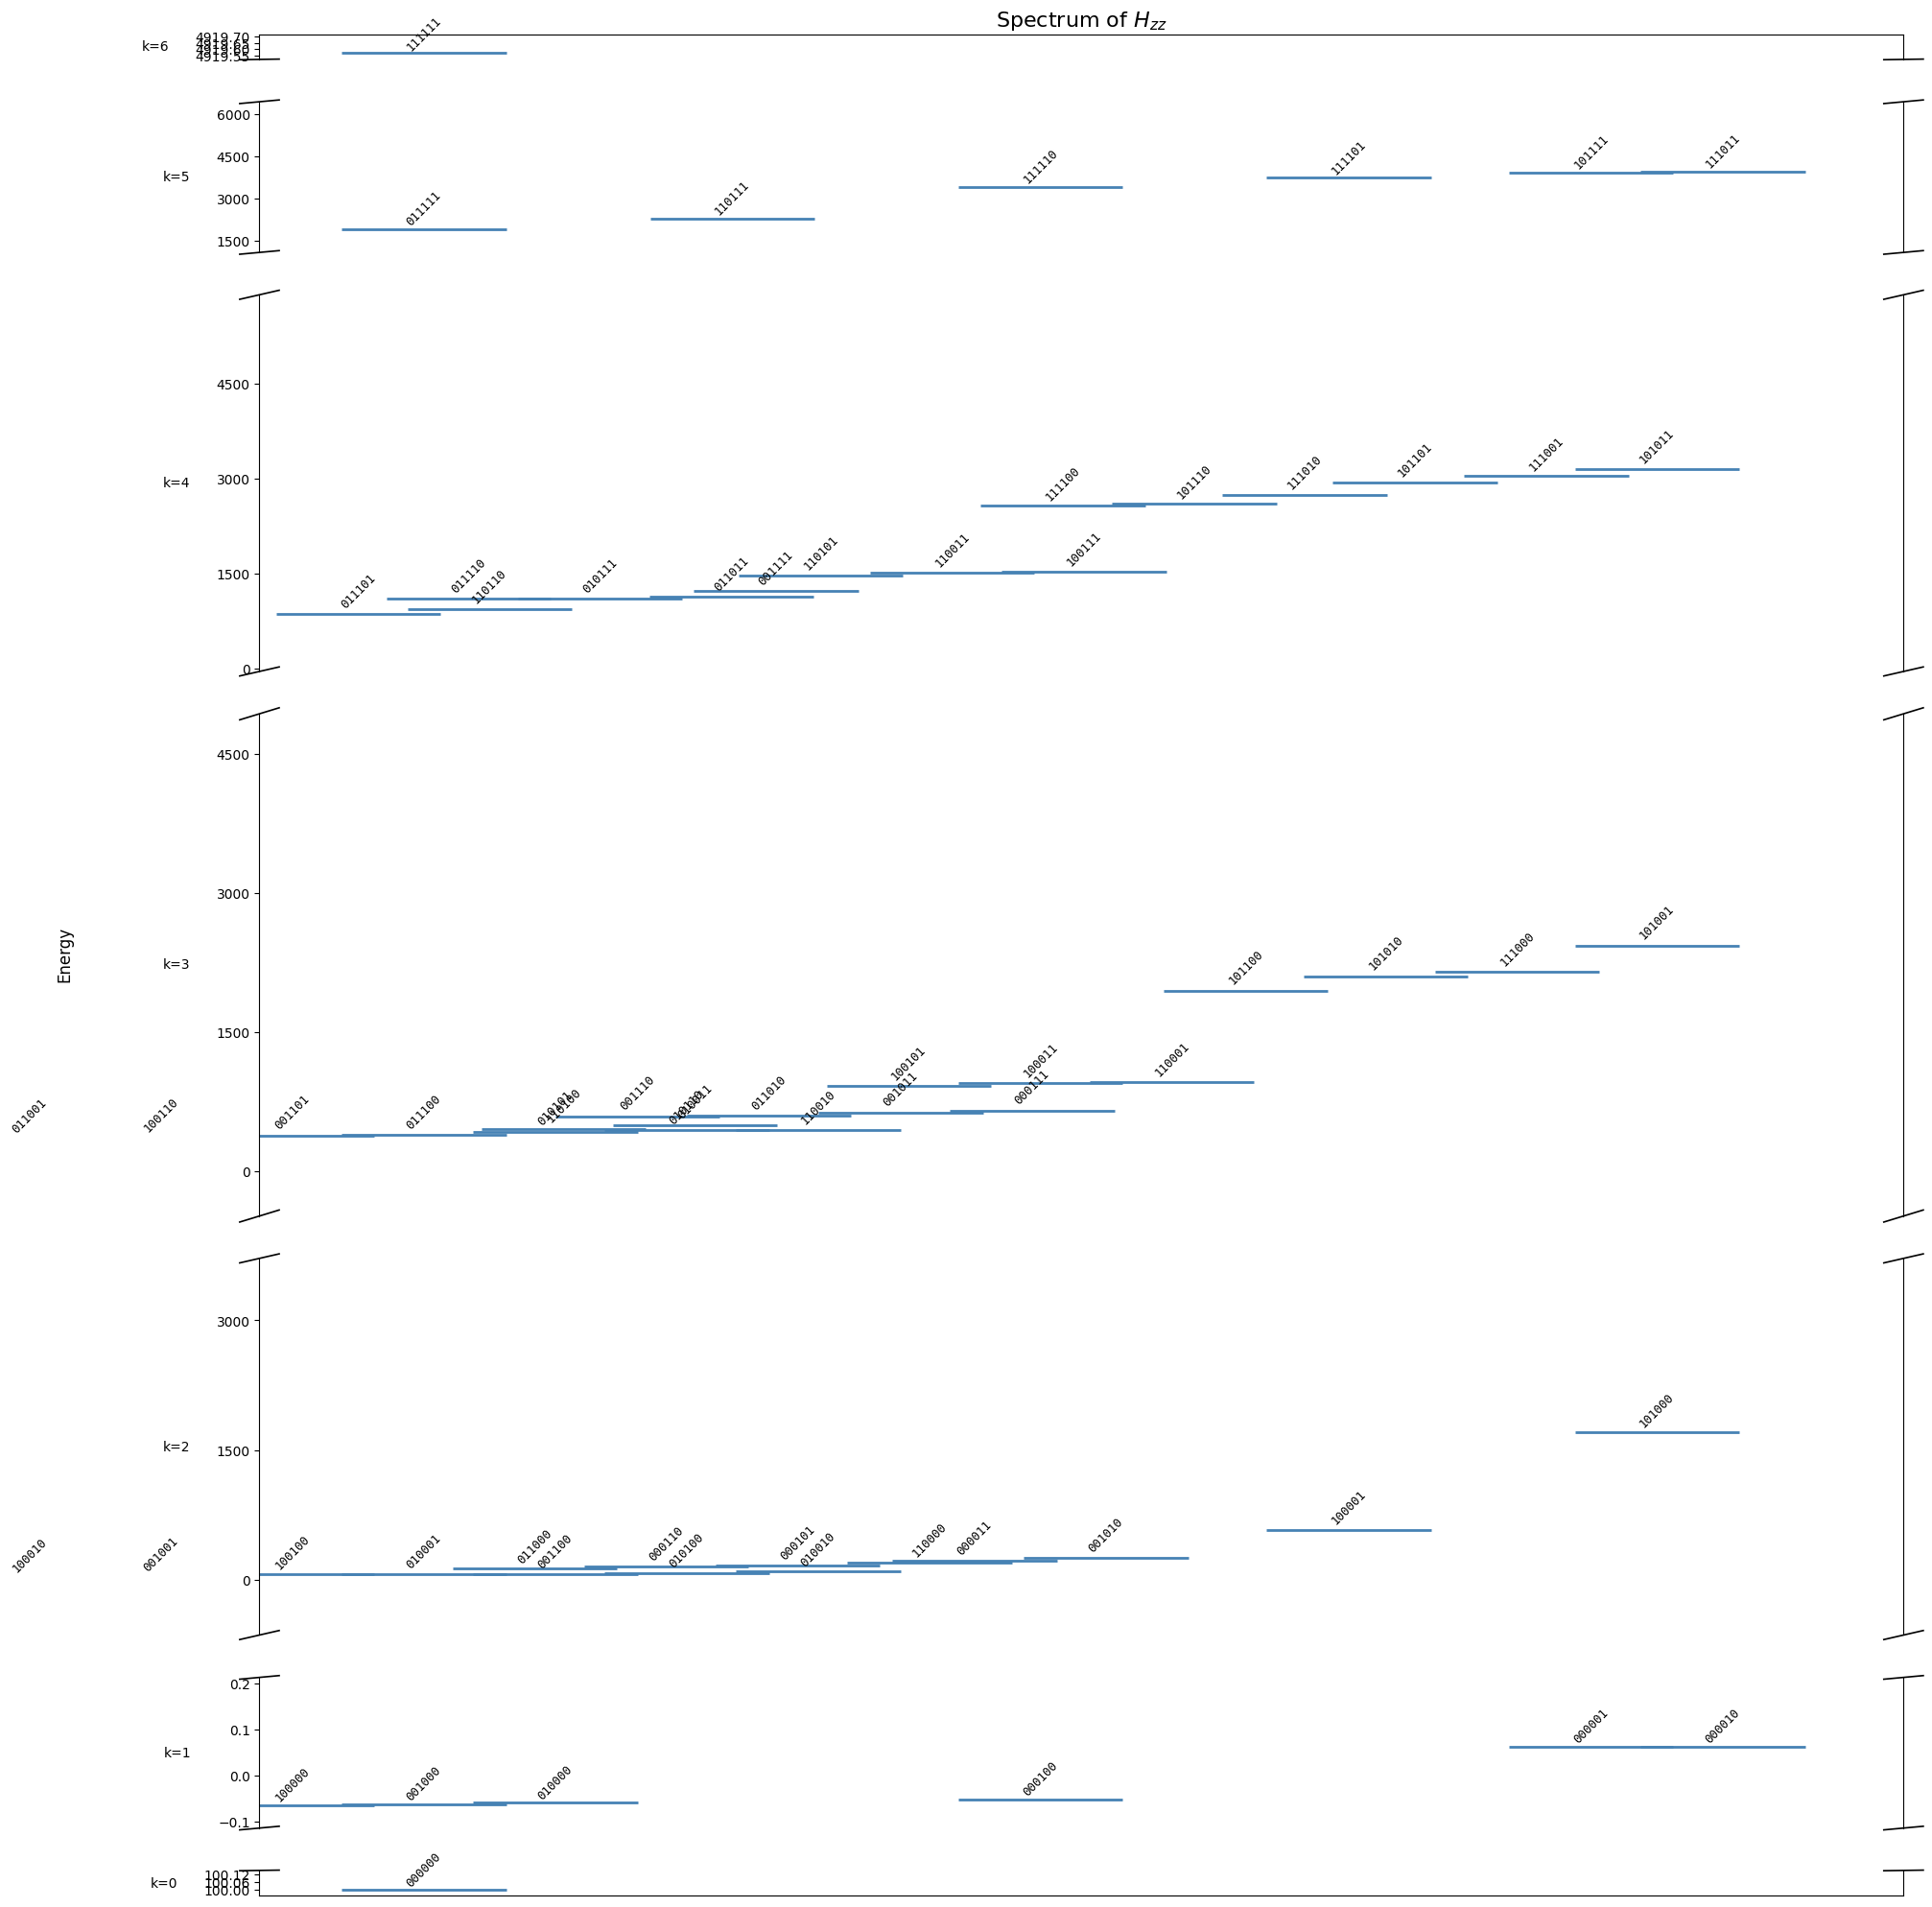

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

#### this should go to the utils
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


def plot_spectrum(
    energies, basis, figsize=(14, 10), fontsize=9, linewidth=2.0, label_offset=0.02
):
    """
    Plot energy spectrum split by particle number (Hamming weight).
    Each panel corresponds to a fixed number of excitations.

    Parameters
    ----------
    energies : array, shape (N,)
    basis : array, shape (N, n_qubits)
    figsize : tuple
    fontsize : int
    linewidth : float
    label_offset : float
        Vertical offset of labels above lines, as fraction of span.
    """
    energies = np.real(np.array(energies))
    labels = ["".join(map(str, row)) for row in basis]

    # --- split by Hamming weight ---
    hamming = basis.sum(axis=1)
    unique_sectors = np.sort(np.unique(hamming))

    splits = []
    sector_labels = []
    for k in unique_sectors:
        idx = np.where(hamming == k)[0]
        idx = idx[np.argsort(energies[idx])]
        splits.append(idx)
        sector_labels.append(k)

    # highest particle number at top
    splits = splits[::-1]
    sector_labels = sector_labels[::-1]

    n_panels = len(splits)
    heights = [max(len(s), 1) for s in splits]

    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=figsize,
        gridspec_kw={"height_ratios": heights},
        squeeze=False,
    )
    axes = axes.flatten()

    for ax, group, k in zip(axes, splits, sector_labels):
        es = energies[group]
        ls = [labels[i] for i in group]
        n = len(es)

        span = es.max() - es.min()
        degen_tol = max(span * 0.05, 1e-6)

        # cluster nearly-degenerate levels into columns
        columns = []
        for i, e in enumerate(es):
            placed = False
            for col in columns:
                if abs(e - es[col[0]]) < degen_tol:
                    col.append(i)
                    placed = True
                    break
            if not placed:
                columns.append([i])

        n_cols = len(columns)
        col_x = np.linspace(0.1, 0.85, max(n_cols, 1))

        for col_idx, col in enumerate(columns):
            cx = col_x[col_idx]
            n_in_col = len(col)
            if n_in_col > 1:
                xs = np.linspace(
                    cx - 0.04 * (n_in_col - 1), cx + 0.04 * (n_in_col - 1), n_in_col
                )
            else:
                xs = [cx]

            for x, idx in zip(xs, col):
                e = es[idx]
                label = ls[idx]
                ax.hlines(e, x - 0.05, x + 0.05, linewidth=linewidth, color="steelblue")
                ax.text(
                    x,
                    e + label_offset * max(span, 0.1),
                    label,
                    va="bottom",
                    ha="center",
                    fontsize=fontsize,
                    fontfamily="monospace",
                    rotation=45,
                )

        margin = max(span * 0.4, 0.05)
        ax.set_ylim(es.min() - margin, es.max() + margin * 3.0)
        ax.set_xlim(0, 1.0)
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

        formatter = ScalarFormatter(useOffset=False)
        formatter.set_scientific(False)
        ax.yaxis.set_major_formatter(formatter)

        # label sector on right
        ax.set_ylabel(f"k={k}", fontsize=10, rotation=0, labelpad=30, va="center")

    # --- broken axis styling ---
    for ax in axes[:-1]:
        ax.spines["bottom"].set_visible(False)
        ax.tick_params(bottom=False)
    for ax in axes[1:]:
        ax.spines["top"].set_visible(False)

    # break marks
    d = 0.012
    for ax_top, ax_bot in zip(axes[:-1], axes[1:]):
        for ax, y in [(ax_top, 0), (ax_bot, 1)]:
            kw = dict(color="k", clip_on=False, linewidth=1.2, transform=ax.transAxes)
            ax.plot((-d, +d), (y - d, y + d), **kw)
            ax.plot((1 - d, 1 + d), (y - d, y + d), **kw)

    axes[0].set_title(r"Spectrum of $H_{zz}$", fontsize=16)
    fig.text(0.02, 0.5, "Energy", va="center", rotation="vertical", fontsize=12)

    plt.tight_layout()
    plt.show()


plot_spectrum(longitudinal_hamiltonian.diag(), basis, figsize=(20, 20))

### Part of the second step is to introduce the transverse field term

We add the transverse field

In [46]:
# the transverse field
transverse_hamiltonian = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    transverse_hamiltonian += SpinOperator(
        [("x", i)], coupling=[d_opt[i] / np.sqrt(2)], size=n_qubits, verbose=1
    ).qutip_op

#### Compute the spectrum of the full Hamiltonian

Once that we compute the spectrum, we expect that our ground state lies in the subspace near the $E_0=0$ region, Let's see what we get

In [47]:
total_hamiltonian = longitudinal_hamiltonian + transverse_hamiltonian
eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
    total_hamiltonian.eigenstates()
)

#### Check the structure of the effective Hamiltonian to control the longitudinal couplings $g_{AA}$

In [48]:
print(eigenvalues_total_hamiltonian[:3])

print(fidelity(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx]))

[-0.11981075 -0.0896377  -0.0809076 ]
0.9994720875594466


#### Adiabatic State Preparation

We divide the initialization of the total hamiltonian, since the driver is just the 0-th component of the Z hamiltonian. We just need to tune the initialization of the other components

In [49]:
# get the total particle constrain
gamma = 8
ntot = 1
# we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[(2 + c_matrix[i, j]) * gamma],
            size=n_qubits,
            verbose=1,
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

total_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
)
# the transverse field is part of the variable hamiltonian
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    total_hamiltonian += SpinOperator(
        [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
    ).qutip_op

Then the driver Hamiltonian

In [50]:
# get the total particle constrain
ntot = 1
# we define the effective longitudianl field that contributes to the driver hamiltonian hamiltonian of Be 6
external_field = np.zeros(diagonal_elements.shape[0])
external_field[0] = diagonal_elements[0]
print(external_field)

effective_longitudinal_field = (external_field) / (gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[(2 + c_matrix[i, j]) * gamma],
            size=n_qubits,
            verbose=1,
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

driver_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
)

print((driver_hamiltonian.full().diagonal()))
idx_init = np.argsort(driver_hamiltonian.full().diagonal())[0]

[-9.3151  0.      0.      0.      0.      0.    ]
[  8.        +0.j   0.        +0.j   0.        +0.j  18.32763639+0.j
   0.        +0.j  13.50379719+0.j  12.5873296 +0.j  52.41876319+0.j
   0.        +0.j   3.48455251+0.j  20.89444343+0.j  50.70663233+0.j
   5.88571673+0.j  30.87406644+0.j  47.36748976+0.j  98.68347586+0.j
   0.        +0.j   5.69329873+0.j   7.99276419+0.j  40.01369931+0.j
   6.59862935+0.j  33.79572527+0.j  35.17872314+0.j  88.70345545+0.j
  10.74719311+0.j  27.92504435+0.j  47.63440072+0.j  91.13988835+0.j
  31.2315392 +0.j  69.91318763+0.j  88.70607641+0.j 153.71536123+0.j
  -1.1643875 +0.j  45.49919591+0.j   1.63092869+0.j  74.62214849+0.j
   4.14688571+0.j  72.31426631+0.j  27.5295315 +0.j 122.0245485 +0.j
 135.48096362+0.j 193.62909954+0.j 167.17072324+0.j 251.64649555+0.j
 154.67795357+0.j 234.32988668+0.j 206.95504278+0.j 312.93461229+0.j
  15.2791908 +0.j  75.63607294+0.j  34.06727118+0.j 120.75178971+0.j
  35.18909336+0.j 117.04977269+0.j  74.56450334+0.j 1

Then we get the state preparation, initializing the state and evolving the interpolate hamiltonian

Time evolution

In [51]:
#### Initialize the state and convert the hamiltonians
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

total_hamiltonian_sparse = total_hamiltonian.data.as_scipy()
driver_hamiltonian_sparse = driver_hamiltonian.data.as_scipy()
print(total_hamiltonian_sparse)
print("Hilbert space dimension:", total_hamiltonian_sparse.shape[0])

# initialize the state
psi = np.zeros(basis.shape[0])
print(basis[idx_init])
psi[idx_init] = 1.0

print(psi.conj().T @ driver_hamiltonian_sparse @ psi)

#### start the time evolution

nlevels = 2
tau = 50
time_steps = int(10 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]
spectrum = np.zeros((time_steps, nlevels))
energy = np.zeros(time_steps)

for i, t in enumerate(time):
    hamiltonian_t_sparse = (1 - t / tau) * driver_hamiltonian_sparse + (
        t / tau
    ) * total_hamiltonian_sparse
    psi = expm_multiply(-1j * delta_t * hamiltonian_t_sparse, psi)

    # Dense diagonalization: robust, no ARPACK convergence issues.
    # Only keep the nlevels lowest eigenvalues/vectors.
    hamiltonian_t_dense = hamiltonian_t_sparse.toarray()
    eigenvalues_all, eigenvectors_all = np.linalg.eigh(hamiltonian_t_dense)
    # eigh already returns eigenvalues in ascending order, but slice explicitly
    # to make the "lowest nlevels" intent unambiguous regardless of that guarantee
    idx = np.argsort(eigenvalues_all)[:nlevels]
    eigenvalues = eigenvalues_all[idx]
    eigenvectors = eigenvectors_all[:, idx]

    spectrum[i] = eigenvalues
    energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))

print("final energy=", psi.conj().dot(total_hamiltonian_sparse.dot(psi)))

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 448 stored elements and shape (64, 64)>
  Coords	Values
  (0, 0)	(8+0j)
  (0, 1)	(0.8025815469665158+0j)
  (0, 2)	(-0.781415471256123+0j)
  (0, 4)	(-0.5615683534744723+0j)
  (0, 8)	(-0.6799047507112889+0j)
  (0, 16)	(0.7250345004773969+0j)
  (0, 32)	(-0.640023713365902+0j)
  (1, 0)	(0.8025815469665158+0j)
  (1, 1)	(0.7740977680583239+0j)
  (1, 3)	(-0.781415471256123+0j)
  (1, 5)	(-0.5615683534744723+0j)
  (1, 9)	(-0.6799047507112889+0j)
  (1, 17)	(0.7250345004773969+0j)
  (1, 33)	(-0.640023713365902+0j)
  (2, 0)	(-0.781415471256123+0j)
  (2, 2)	(0.7740977680583239+0j)
  (2, 3)	(0.8025815469665158+0j)
  (2, 6)	(-0.5615683534744723+0j)
  (2, 10)	(-0.6799047507112889+0j)
  (2, 18)	(0.7250345004773969+0j)
  (2, 34)	(-0.640023713365902+0j)
  (3, 1)	(-0.781415471256123+0j)
  (3, 2)	(0.8025815469665158+0j)
  (3, 3)	(19.875831929409323+0j)
  (3, 7)	(-0.5615683534744723+0j)
  :	:
  (60, 56)	(-0.5615683534744723+0j)
  (60, 60)	(202

/tmp/ipykernel_119912/3979975275.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))


final energy= (-1.352184774688035+0j)


Results of the QA state preparation

fidelity= 0.8826911260502237 -0.11981075392795026


/tmp/ipykernel_119912/1992767377.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


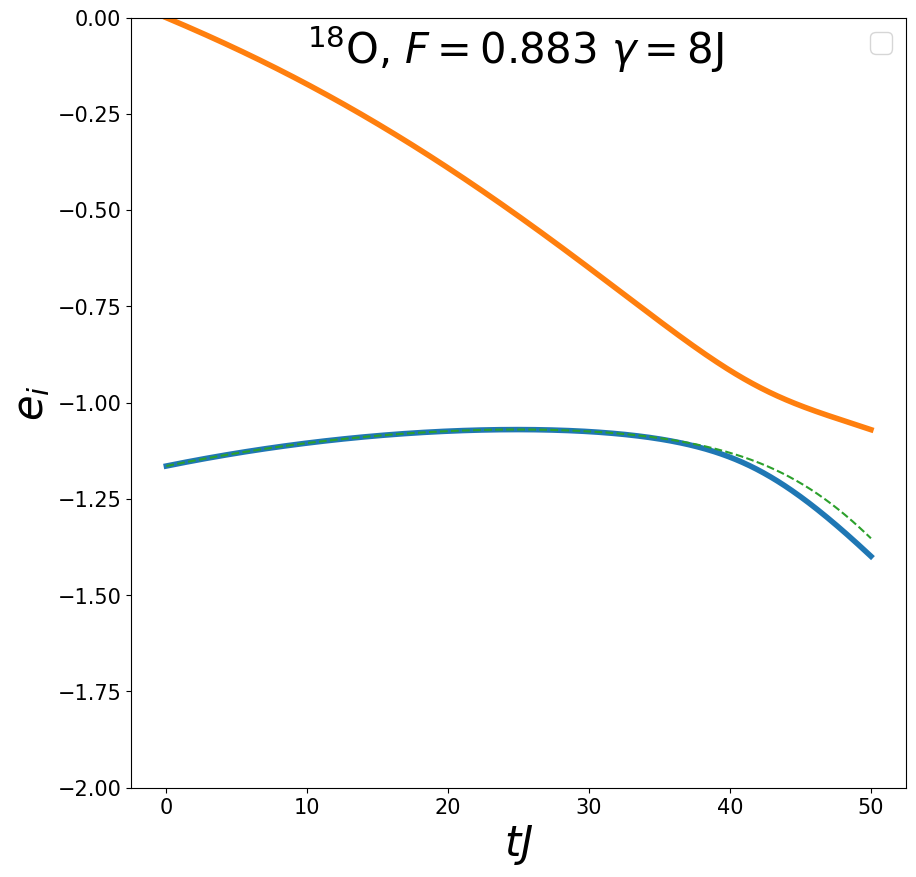

-10.81747819750428


In [52]:
plt.figure(figsize=(10, 10))
plt.plot(time, spectrum, linewidth=4)
plt.plot(time, energy, linestyle="--")
psi_qutip = array_to_qutip(psi, n_qubits)
f_value = fidelity(psi_qutip, eigenstates_total_hamiltonian[0])
print(
    "fidelity=",
    fidelity(psi_qutip, eigenstates_total_hamiltonian[0]),
    eigenvalues_total_hamiltonian[0],
)
plt.text(
    x=10,
    y=-0.12,
    s=r"$^{18}\text{O}$, $F=$" + f"{f_value:.3f} " + r"$\gamma=$" + f"{gamma:.0f}J",
    fontsize=30,
)
plt.xlabel(r"$tJ$", fontsize=30)
plt.ylabel(r"$e_i$", fontsize=30)
plt.legend(fontsize=20)
plt.tick_params(which="major", labelsize=15)
plt.ylim([-2, 0])
plt.show()

print(energy[-1] * gamma)

#### Robstness of the Gadget vs $\gamma$

We study the robustness of the Gadget Hamiltonian tuning the $\gamma$ parameter, to check if we can reduce it to comparable values

In [53]:
from qutip import fidelity

gammas = np.linspace(1, 200, 40)
energy_error = []
fidelities = []
for gamma in gammas:
    # get the total particle constrain
    ntot = 1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (
        gamma
    )

    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[(2 + c_matrix[i, j]) * gamma],
                size=n_qubits,
                verbose=1,
            ).qutip_op

    # then the linear terms
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian = (
        hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
        ).qutip_op

    eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
        total_hamiltonian.eigenstates()
    )
    print(
        eigenvalues_total_hamiltonian[0] * gamma,
        energies_particle_sector[0],
    )
    energy_error.append(
        np.abs(eigenvalues_total_hamiltonian[0] * gamma - energies_particle_sector[0])
        / np.abs(energies_particle_sector[0])
    )
    print(
        "fidelities=",
        qt.fidelity(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx]),
        "\n",
    )
    fidelities.append(
        qt.fidelity(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx])
    )

-13.916101951141098 -11.931788251561521
fidelities= 0.0598535796662107 

-10.878706126247081 -11.931788251561521
fidelities= 0.9289595386722354 

-11.502607202340858 -11.931788251561521
fidelities= 0.9720796114140084 

-11.731222177200417 -11.931788251561521
fidelities= 0.9852619381532197 

-11.832020411035097 -11.931788251561521
fidelities= 0.9909888988567549 

-11.884051990437715 -11.931788251561521
fidelities= 0.9939440385063165 

-11.914104844384468 -11.931788251561521
fidelities= 0.9956530440165885 

-11.932938166850496 -11.931788251561521
fidelities= 0.9967253188838396 

-11.94548552886964 -11.931788251561521
fidelities= 0.9974403754840999 

-11.95425068599476 -11.931788251561521
fidelities= 0.9979402460758605 

-11.960608805464123 -11.931788251561521
fidelities= 0.9983030416944383 

-11.965364297611297 -11.931788251561521
fidelities= 0.9985745042940875 

-11.969012443470264 -11.931788251561521
fidelities= 0.9987828230052742 

-11.9718714069476 -11.931788251561521
fidelities= 0.9

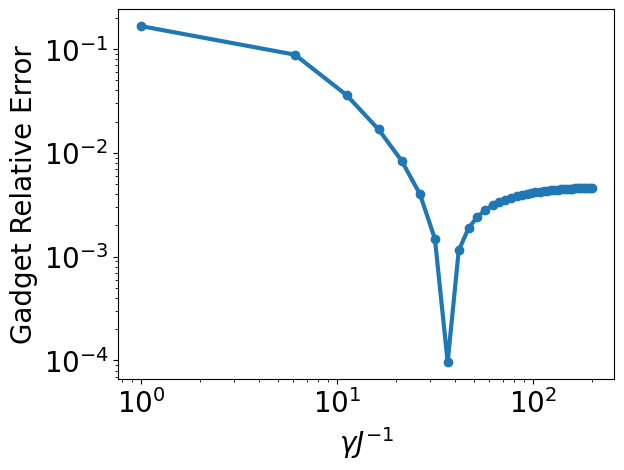

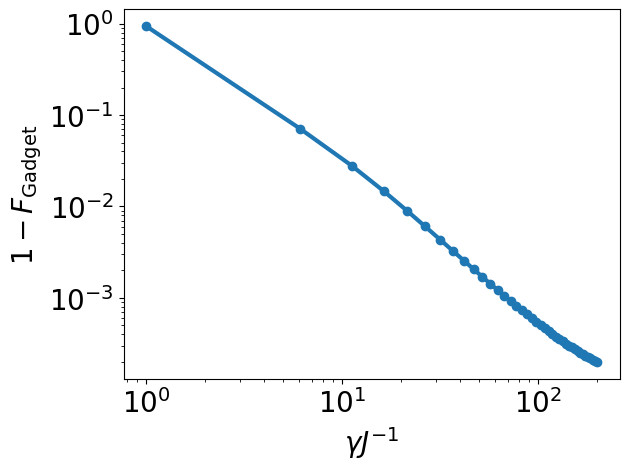

In [54]:
plt.plot(gammas, energy_error, linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel("Gadget Relative Error", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas, 1 - np.array(fidelities), linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$1-F_{\text{Gadget}}$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

#### Robustness of the Gadget vs $\gamma$: without the $c_{AB}$ coupling

We repeat the same $\gamma$ sweep, but this time dropping the $c_{AB}$ correction in the $N_AN_B$ coupling (`total_hamiltonian_wo_cmatrix`), to compare its robustness against the full gadget above.

In [55]:
gammas_wo_cmatrix = np.linspace(1, 200, 40)
energy_error_wo_cmatrix = []
fidelities_wo_cmatrix = []
for gamma in gammas_wo_cmatrix:
    # get the total particle constrain
    ntot = 1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (
        gamma
    )

    # lets start with the Z_A Z_B of the constrain, without the c_matrix contribution
    hamiltonian_zz_wo_cmatrix = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz_wo_cmatrix += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[2 * gamma],
                size=n_qubits,
                verbose=1,
            ).qutip_op

    # then the linear terms
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian_wo_cmatrix = (
        hamiltonian_zz_wo_cmatrix
        + hamiltonian_z
        + gamma * (ntot**2) * identity_qubit_space
    )
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian_wo_cmatrix += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
        ).qutip_op

    (
        eigenvalues_total_hamiltonian_wo_cmatrix,
        eigenstates_total_hamiltonian_wo_cmatrix,
    ) = total_hamiltonian_wo_cmatrix.eigenstates()
    print(
        eigenvalues_total_hamiltonian_wo_cmatrix[0] * gamma,
        energies_particle_sector[0],
    )
    energy_error_wo_cmatrix.append(
        np.abs(
            eigenvalues_total_hamiltonian_wo_cmatrix[0] * gamma
            - energies_particle_sector[0]
        )
        / np.abs(energies_particle_sector[0])
    )
    print(
        "fidelities_wo_cmatrix=",
        qt.fidelity(
            eigenstates_total_hamiltonian_wo_cmatrix[0], eigenstates_nsm[gs_idx]
        ),
        "\n",
    )
    fidelities_wo_cmatrix.append(
        qt.fidelity(
            eigenstates_total_hamiltonian_wo_cmatrix[0], eigenstates_nsm[gs_idx]
        )
    )

-15.856290277487814 -11.931788251561521
fidelities_wo_cmatrix= 0.03764381450407191 

-11.318216244652007 -11.931788251561521
fidelities_wo_cmatrix= 0.9328154022848248 

-11.781476345204922 -11.931788251561521
fidelities_wo_cmatrix= 0.9742972786601585 

-11.933783525297605 -11.931788251561521
fidelities_wo_cmatrix= 0.9860154369343115 

-11.997697390859074 -11.931788251561521
fidelities_wo_cmatrix= 0.9908238568571495 

-12.029895070600748 -11.931788251561521
fidelities_wo_cmatrix= 0.9932296059759904 

-12.048243350874166 -11.931788251561521
fidelities_wo_cmatrix= 0.9945965016801068 

-12.05964846527685 -11.931788251561521
fidelities_wo_cmatrix= 0.9954448363656081 

-12.067206926783607 -11.931788251561521
fidelities_wo_cmatrix= 0.9960065354506585 

-12.072468004588757 -11.931788251561521
fidelities_wo_cmatrix= 0.9963972773136434 

-12.076274522158617 -11.931788251561521
fidelities_wo_cmatrix= 0.9966798753058344 

-12.079116182327562 -11.931788251561521
fidelities_wo_cmatrix= 0.99689078141

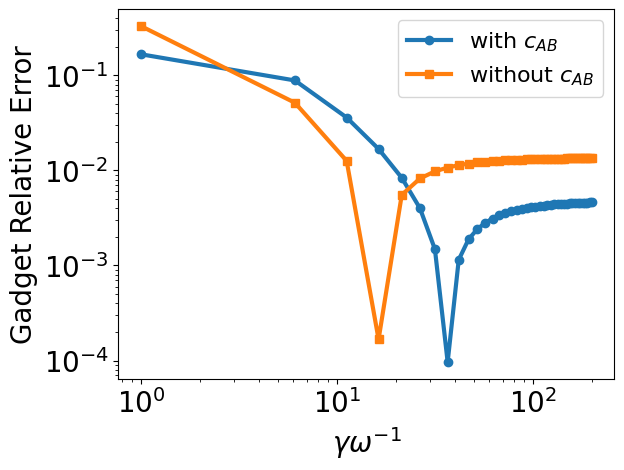

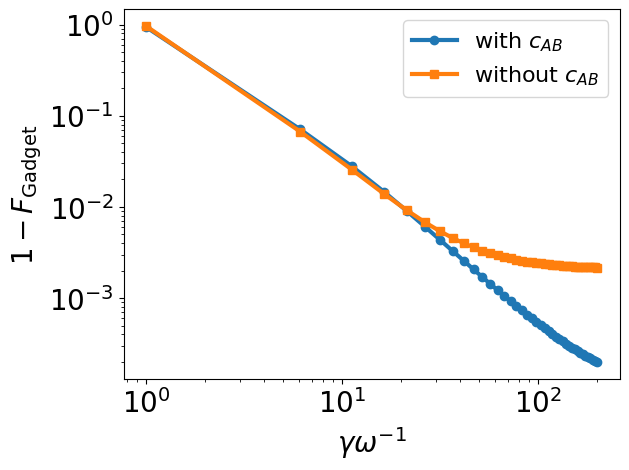

In [56]:
plt.plot(gammas, energy_error, linewidth=3, marker="o", label="with $c_{AB}$")
plt.plot(
    gammas_wo_cmatrix,
    energy_error_wo_cmatrix,
    linewidth=3,
    marker="s",
    label="without $c_{AB}$",
)
plt.xlabel(r"$\gamma \omega^{-1}$", fontsize=20)
plt.ylabel("Gadget Relative Error", fontsize=20)
plt.tick_params(labelsize=20)
plt.legend(fontsize=16)
plt.loglog()
plt.show()

plt.plot(
    gammas, 1 - np.array(fidelities), linewidth=3, marker="o", label="with $c_{AB}$"
)
plt.plot(
    gammas_wo_cmatrix,
    1 - np.array(fidelities_wo_cmatrix),
    linewidth=3,
    marker="s",
    label="without $c_{AB}$",
)
plt.xlabel(r"$\gamma \omega^{-1}$", fontsize=20)
plt.ylabel(r"$1-F_{\text{Gadget}}$", fontsize=20)
plt.tick_params(labelsize=20)
plt.legend(fontsize=16)
plt.loglog()
plt.show()

#### Fidelity vs $\gamma$: with vs without the $c_{AB}$ coupling

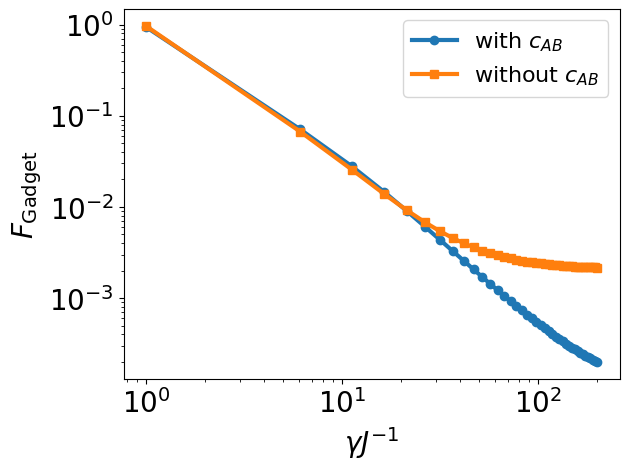

In [57]:
plt.plot(
    gammas, 1 - np.asarray(fidelities), linewidth=3, marker="o", label="with $c_{AB}$"
)
plt.plot(
    gammas_wo_cmatrix,
    1 - np.asarray(fidelities_wo_cmatrix),
    linewidth=3,
    marker="s",
    label="without $c_{AB}$",
)
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$F_{\text{Gadget}}$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.legend(fontsize=16)
plt.show()

#### Ground state wavefunction comparison for selected $\gamma$ values

We pick a few representative $\gamma$ values from the sweep above and compare, bitstring by bitstring, the exact ground state (`psi`) against the ground states of `total_hamiltonian` (with $c_{AB}$) and `total_hamiltonian_wo_cmatrix` (without $c_{AB}$), keeping only components whose $|\text{amplitude}|$ exceeds `threshold` in at least one of the three.

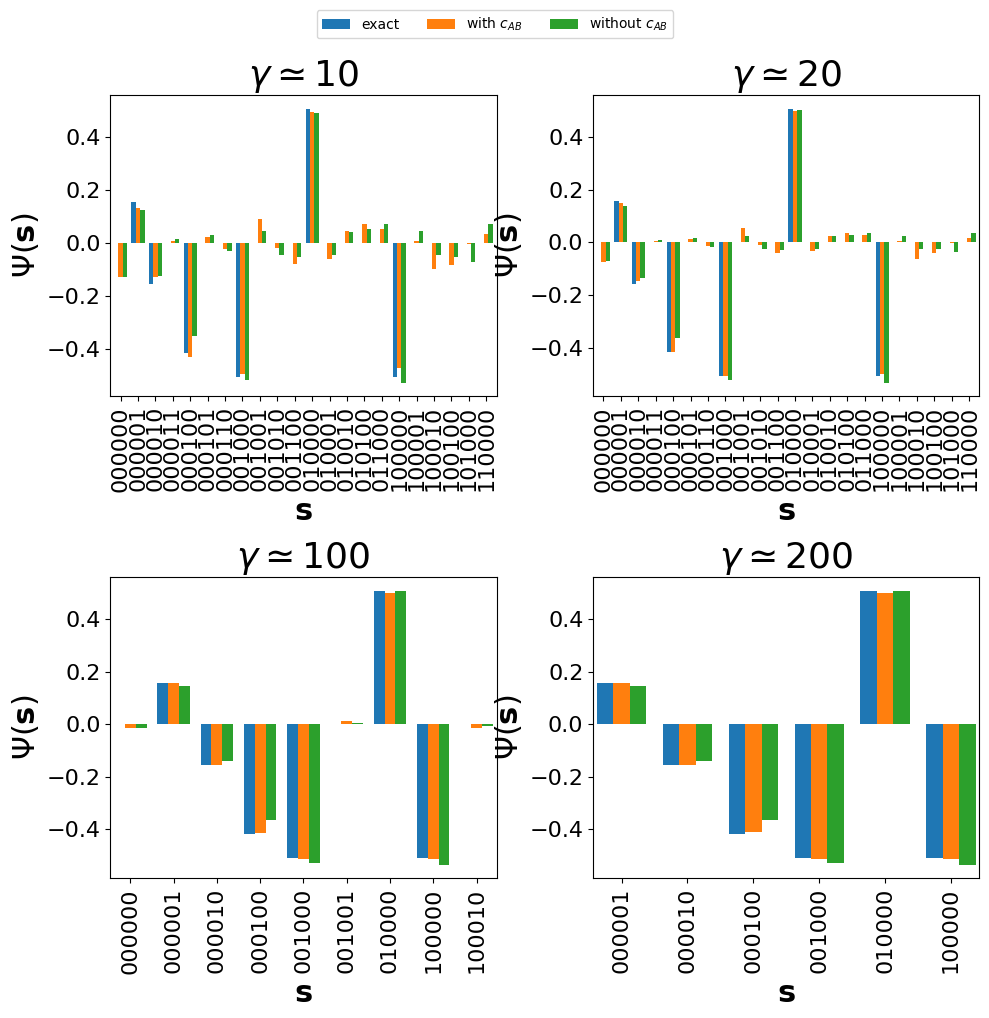

In [58]:
selected_gammas = np.array([10.0, 20.0, 100.0, 200.0])

labels_full = ["".join(map(str, row)) for row in basis]
# recompute the exact ground state locally: the global `psi` gets overwritten
# later by the QA state-preparation cell, so it can't be trusted here
psi_exact = eigenstates_nsm[gs_idx].full().flatten()

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, gamma in zip(axes, selected_gammas):
    ntot = 1
    effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / gamma
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    # then the linear terms (shared between the with/without c_matrix Hamiltonians)
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # with c_matrix
    hamiltonian_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[(2 + c_matrix[i, j]) * gamma],
                size=n_qubits,
                verbose=1,
            ).qutip_op
    total_hamiltonian_gamma = (
        hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )
    for i in range(n_qubits):
        total_hamiltonian_gamma += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / np.sqrt(2)], size=n_qubits, verbose=1
        ).qutip_op
    _, eigenstates_gamma = total_hamiltonian_gamma.eigenstates()
    psi_with = eigenstates_gamma[0].full().flatten()

    # without c_matrix
    hamiltonian_zz_wo = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz_wo += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[2 * gamma],
                size=n_qubits,
                verbose=1,
            ).qutip_op
    total_hamiltonian_wo_cmatrix_gamma = (
        hamiltonian_zz_wo + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )
    for i in range(n_qubits):
        total_hamiltonian_wo_cmatrix_gamma += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / np.sqrt(2)], size=n_qubits, verbose=1
        ).qutip_op
    _, eigenstates_wo_cmatrix_gamma = total_hamiltonian_wo_cmatrix_gamma.eigenstates()
    psi_without = eigenstates_wo_cmatrix_gamma[0].full().flatten()

    # eigenvectors carry an arbitrary overall sign; align both to the exact state's
    # sign convention (via the sign of their real overlap) before comparing components
    sign_with = np.sign(np.real(np.vdot(psi_exact, psi_with))) or 1.0
    sign_without = np.sign(np.real(np.vdot(psi_exact, psi_without))) or 1.0
    psi_with = psi_with * sign_with
    psi_without = psi_without * sign_without

    # keep bitstrings where any of the three has a component above threshold
    mask = (
        (np.abs(psi_exact) > threshold)
        | (np.abs(psi_with) > threshold)
        | (np.abs(psi_without) > threshold)
    )
    sel = np.where(mask)[0]
    sel_labels = [labels_full[k] for k in sel]

    x = np.arange(len(sel))
    width = 0.25

    ax.bar(x - width, np.real(psi_exact[sel]), width=width, label="exact")
    ax.bar(x, np.real(psi_with[sel]), width=width, label="with $c_{AB}$")
    ax.bar(x + width, np.real(psi_without[sel]), width=width, label="without $c_{AB}$")
    ax.set_xticks(x)
    ax.set_xticklabels(sel_labels, rotation=90, fontsize=16)
    ax.set_xlabel(r"$\mathbf{s}$", fontsize=22)
    ax.set_ylabel(r"$\Psi(\mathbf{s})$", fontsize=22)
    ax.set_title(f"$\\gamma \\simeq {gamma:.0f}$", fontsize=26)
    ax.tick_params(axis="y", labelsize=16)
    ax.margins(x=0.01)

handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels_legend,
    loc="upper center",
    ncol=3,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.02),
)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.subplots_adjust(hspace=0.6, wspace=0.25)
plt.show()

#### What about the state preparation using QA then ??

We repeat the $\gamma$ sweep from above, but this time actually preparing the ground state via quantum adiabatic (QA) time evolution instead of exact diagonalization, still keeping the $c_{AB}$ correction (`total_hamiltonian` built with `c_matrix`) in the target Hamiltonian.

In [72]:
print((2 - 0.65) / 2)

0.675


In [73]:
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

fidelities_qa_with_cmatrix = []
energy_error_qa_with_cmatrix = []
gammas_qa_with_cmatrix = np.linspace(1, 100, 10)
for gamma in gammas_qa_with_cmatrix:
    # get the total particle constrain
    ntot = 1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (
        gamma
    )

    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[(2 + c_matrix[i, j]) * gamma],
                size=n_qubits,
                verbose=1,
            ).qutip_op

    # then the linear terms
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian = (
        hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
        ).qutip_op
    #### Initialize the state and convert the hamiltonians

    total_hamiltonian_sparse = total_hamiltonian.data.as_scipy()
    driver_hamiltonian_sparse = driver_hamiltonian.data.as_scipy()
    # initialize the state
    psi = np.zeros(basis.shape[0])
    psi[idx_init] = 1.0

    #### start the time evolution

    nlevels = 3
    tau = 30 * gamma / 0.67  # correction of the energy scale
    time_steps = int(30 * tau)
    time = np.linspace(0, tau, time_steps)
    delta_t = time[1] - time[0]
    spectrum = np.zeros((time_steps, nlevels))
    energy = np.zeros(time_steps)
    for i, t in enumerate(time):
        hamiltonian_t_sparse = (1 - t / tau) * driver_hamiltonian_sparse + (
            t / tau
        ) * total_hamiltonian_sparse
        psi = expm_multiply(-1j * delta_t * hamiltonian_t_sparse, psi)

        # Dense diagonalization: robust, no ARPACK convergence failures.
        # Symmetrize defensively (guards against tiny float asymmetry from
        # the SpinOperator construction order), then take only the lowest
        # nlevels eigenpairs.
        H_t_dense = hamiltonian_t_sparse.toarray()
        H_t_sym = 0.5 * (H_t_dense + H_t_dense.T)
        # eigenvalues_all, eigenvectors_all = np.linalg.eigh(H_t_sym)
        # idx = np.argsort(eigenvalues_all)[:nlevels]
        # eigenvalues = eigenvalues_all[idx]
        # eigenvectors = eigenvectors_all[:, idx]

        # spectrum[i] = eigenvalues
        energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))
    psi_qutip = array_to_qutip(psi, n_qubits)
    # benchmark against the exact particle-sector energy / NSM ground state,
    # same reference used by the with/without c_AB eigenstate-fidelity sweep above
    energy_error_qa_with_cmatrix.append(
        np.abs(energy[-1] * gamma - energies_particle_sector[0])
        / np.abs(energies_particle_sector[0])
    )
    f_value = fidelity(psi_qutip, eigenstates_nsm[gs_idx])
    fidelities_qa_with_cmatrix.append(f_value)
    print(gamma)
    print("energy=", energy[-1] * gamma)
    print("fidelity=", f_value)

/tmp/ipykernel_119912/314883403.py:84: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))


1.0
energy= -13.42214612731491
fidelity= 0.02553399133348379
12.0
energy= -11.552759959056557
fidelity= 0.9749098591802359
23.0
energy= -11.849323772315575
fidelity= 0.9917152244868531
34.0
energy= -11.91969532077228
fidelity= 0.9955391639739379
45.0
energy= -11.943956130614007
fidelity= 0.9966435003931415
56.0
energy= -11.948253395116188
fidelity= 0.9960387336985975
67.0
energy= -11.938467521147048
fidelity= 0.9937586254048587
78.0
energy= -11.917862344659396
fidelity= 0.9899824380919814
89.0
energy= -11.889305105186613
fidelity= 0.9850189224585957
100.0
energy= -11.85526789413541
fidelity= 0.979194882187503


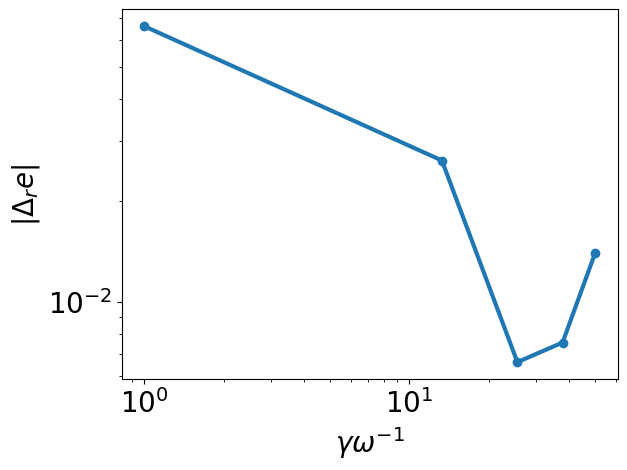

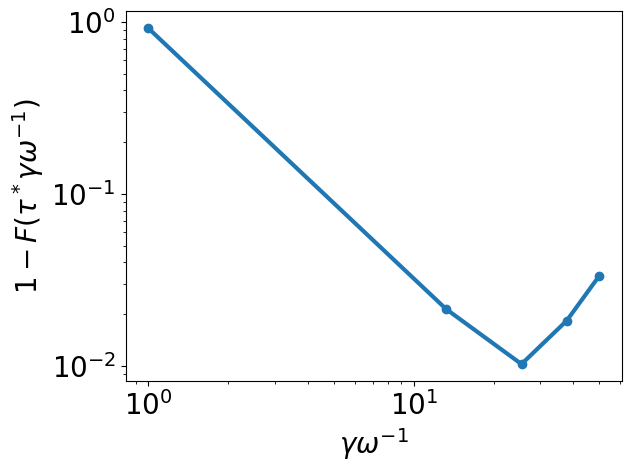

In [65]:
plt.plot(gammas_qa_with_cmatrix, energy_error_qa_with_cmatrix, linewidth=3, marker="o")
plt.xlabel(r"$\gamma \omega^{-1}$", fontsize=20)
plt.ylabel(r"$|\Delta_r e|$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(
    gammas_qa_with_cmatrix,
    1 - np.array(fidelities_qa_with_cmatrix),
    linewidth=3,
    marker="o",
)
plt.xlabel(r"$\gamma \omega^{-1}$", fontsize=20)
plt.ylabel(r"$1-F(\tau^* \gamma \omega^{-1} )$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

#### QA State Preparation vs $\gamma$: without the $c_{AB}$ coupling

We repeat the QA sweep above, but now drop the $c_{AB}$ correction from both the driver and the target Hamiltonian (`driver_hamiltonian_wo_cmatrix`, `total_hamiltonian_wo_cmatrix`), mirroring the exact-diagonalization with/without $c_{AB}$ comparison done earlier for the robustness sweep.

In [66]:
# driver Hamiltonian without the c_AB correction, analogous to the `driver_hamiltonian` cell
# above but with the bare "2" ZZ coupling used by `total_hamiltonian_wo_cmatrix`.
# Rebuilt self-contained at the same reference gamma=8 used for `driver_hamiltonian`,
# rather than reusing leftover loop variables from the with-c_AB QA sweep.
gamma = 8
ntot = 1
external_field = np.zeros(diagonal_elements.shape[0])
external_field[0] = diagonal_elements[0]
effective_longitudinal_field = external_field / gamma

hamiltonian_zz_driver_wo_cmatrix = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz_driver_wo_cmatrix += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[2 * gamma],
            size=n_qubits,
            verbose=1,
        ).qutip_op

hamiltonian_z_driver_wo_cmatrix = 0.0
for i in range(n_qubits):
    hamiltonian_z_driver_wo_cmatrix += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

driver_hamiltonian_wo_cmatrix = (
    hamiltonian_zz_driver_wo_cmatrix
    + hamiltonian_z_driver_wo_cmatrix
    + gamma * (ntot**2) * identity_qubit_space
)

print((driver_hamiltonian_wo_cmatrix.full().diagonal()))
idx_init_wo_cmatrix = np.argsort(driver_hamiltonian_wo_cmatrix.full().diagonal())[0]

[  8.       +0.j   0.       +0.j   0.       +0.j   8.       +0.j
   0.       +0.j   8.       +0.j   8.       +0.j  32.       +0.j
   0.       +0.j   8.       +0.j   8.       +0.j  32.       +0.j
   8.       +0.j  32.       +0.j  32.       +0.j  72.       +0.j
   0.       +0.j   8.       +0.j   8.       +0.j  32.       +0.j
   8.       +0.j  32.       +0.j  32.       +0.j  72.       +0.j
   8.       +0.j  32.       +0.j  32.       +0.j  72.       +0.j
  32.       +0.j  72.       +0.j  72.       +0.j 128.       +0.j
  -1.1643875+0.j   6.8356125+0.j   6.8356125+0.j  30.8356125+0.j
   6.8356125+0.j  30.8356125+0.j  30.8356125+0.j  70.8356125+0.j
   6.8356125+0.j  30.8356125+0.j  30.8356125+0.j  70.8356125+0.j
  30.8356125+0.j  70.8356125+0.j  70.8356125+0.j 126.8356125+0.j
   6.8356125+0.j  30.8356125+0.j  30.8356125+0.j  70.8356125+0.j
  30.8356125+0.j  70.8356125+0.j  70.8356125+0.j 126.8356125+0.j
  30.8356125+0.j  70.8356125+0.j  70.8356125+0.j 126.8356125+0.j
  70.8356125+0.j 126.8356

In [74]:
fidelities_qa_wo_cmatrix = []
energy_error_qa_wo_cmatrix = []
gammas_qa_wo_cmatrix = np.linspace(1, 50, 5)
for gamma in gammas_qa_wo_cmatrix:
    # get the total particle constrain
    ntot = 1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (
        gamma
    )

    # lets start with the Z_A Z_B of the constrain, without the c_matrix contribution
    hamiltonian_zz_wo_cmatrix = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz_wo_cmatrix += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[2 * gamma],
                size=n_qubits,
                verbose=1,
            ).qutip_op

    # then the linear terms
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian_wo_cmatrix = (
        hamiltonian_zz_wo_cmatrix
        + hamiltonian_z
        + gamma * (ntot**2) * identity_qubit_space
    )
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        total_hamiltonian_wo_cmatrix += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
        ).qutip_op
    #### Initialize the state and convert the hamiltonians

    total_hamiltonian_wo_cmatrix_sparse = total_hamiltonian_wo_cmatrix.data.as_scipy()
    driver_hamiltonian_wo_cmatrix_sparse = driver_hamiltonian_wo_cmatrix.data.as_scipy()
    # initialize the state
    psi = np.zeros(basis.shape[0])
    psi[idx_init_wo_cmatrix] = 1.0

    #### start the time evolution

    nlevels = 3
    tau = 20 * gamma
    time_steps = int(30 * tau)
    time = np.linspace(0, tau, time_steps)
    delta_t = time[1] - time[0]
    spectrum = np.zeros((time_steps, nlevels))
    energy = np.zeros(time_steps)
    for i, t in enumerate(time):
        hamiltonian_t_sparse = (1 - t / tau) * driver_hamiltonian_wo_cmatrix_sparse + (
            t / tau
        ) * total_hamiltonian_wo_cmatrix_sparse
        psi = expm_multiply(-1j * delta_t * hamiltonian_t_sparse, psi)

        H_t_dense = hamiltonian_t_sparse.toarray()
        H_t_sym = 0.5 * (H_t_dense + H_t_dense.T)
        # eigenvalues_all, eigenvectors_all = np.linalg.eigh(H_t_sym)
        # idx = np.argsort(eigenvalues_all)[:nlevels]
        # eigenvalues = eigenvalues_all[idx]
        # eigenvectors = eigenvectors_all[:, idx]

        # spectrum[i] = eigenvalues
        energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))
    psi_qutip = array_to_qutip(psi, n_qubits)
    energy_error_qa_wo_cmatrix.append(
        np.abs(energy[-1] * gamma - energies_particle_sector[0])
        / np.abs(energies_particle_sector[0])
    )
    f_value = fidelity(psi_qutip, eigenstates_nsm[gs_idx])
    fidelities_qa_wo_cmatrix.append(f_value)
    print(gamma)
    print("energy=", energy[-1] * gamma)
    print("fidelity=", f_value)

/tmp/ipykernel_119912/487780094.py:78: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))


1.0
energy= -15.292612900615012
fidelity= 0.07286762275491171
13.25
energy= -11.857578557299076
fidelity= 0.9801086886622057
25.5
energy= -12.01841268418268
fidelity= 0.9923115789055565
37.75
energy= -12.032626913600724
fidelity= 0.9928273128499847
50.0
energy= -11.994404074873607
fidelity= 0.9873409495163051


#### QA Fidelity vs $\gamma$: with vs without the $c_{AB}$ coupling

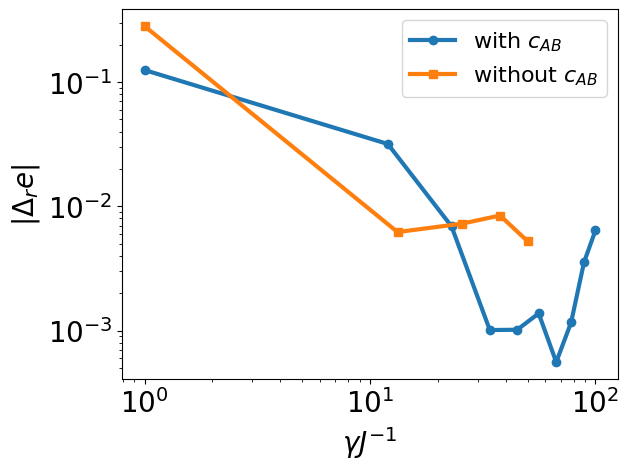

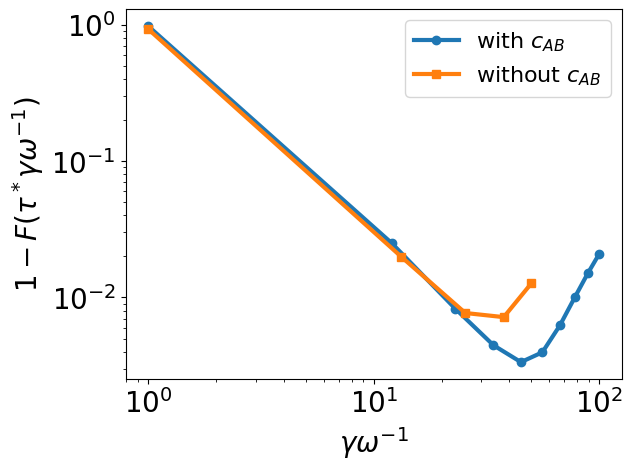

In [75]:
plt.plot(
    gammas_qa_with_cmatrix,
    energy_error_qa_with_cmatrix,
    linewidth=3,
    marker="o",
    label="with $c_{AB}$",
)
plt.plot(
    gammas_qa_wo_cmatrix,
    energy_error_qa_wo_cmatrix,
    linewidth=3,
    marker="s",
    label="without $c_{AB}$",
)
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$|\Delta_r e|$", fontsize=20)
plt.tick_params(labelsize=20)
plt.legend(fontsize=16)
plt.loglog()
plt.show()

plt.plot(
    gammas_qa_with_cmatrix,
    1 - np.array(fidelities_qa_with_cmatrix),
    linewidth=3,
    marker="o",
    label="with $c_{AB}$",
)
plt.plot(
    gammas_qa_wo_cmatrix,
    1 - np.array(fidelities_qa_wo_cmatrix),
    linewidth=3,
    marker="s",
    label="without $c_{AB}$",
)
plt.xlabel(r"$\gamma \omega^{-1}$", fontsize=20)
plt.ylabel(r"$1-F(\tau^* \gamma \omega^{-1} )$", fontsize=20)
plt.tick_params(labelsize=20)
plt.legend(fontsize=16)
plt.loglog()
plt.show()